In [39]:
%autoreload 2

import sys
import time
import pickle
import warnings
import itertools
import numpy as np
import pandas as pd
from glob import glob
from tqdm.auto import tqdm

from sklearn.utils import shuffle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut, cross_val_predict, GridSearchCV
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_classif
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning
from sklearn.base import BaseEstimator, TransformerMixin

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import fdrcorrection

import scipy.io as sio
from scipy.stats import ttest_1samp, ttest_rel, ttest_ind

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from FAT.toolbox import FunctionalAnalysisToolkit
from FAT import stats, viz

In [35]:
# matlab and seaborn config
mpl.rcParams['text.usetex'] = True
sns.set(style="whitegrid")
def add_significance(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1 + x2) * .5, y + h, text, ha='center', va='bottom', color='black')

In [7]:
fat = FunctionalAnalysisToolkit()

data_path = '/mnt/hdd2/associative_learning/analysis/estimates/single_trial_gm_hp/'
roi_path = '/mnt/hdd2/associative_learning/masks/drawn_regions/'

subjects = ['S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S15', 'S17']
regions = ['DG', 'CA1', 'CA2', 'CA3', 'SUB']
hemispheres = ['LH', 'RH']

dataset = {}
for subject in tqdm(subjects):
    dataset[subject] = {}
    for hemisphere in tqdm(hemispheres, leave=False):
        dataset[subject][hemisphere] = {}
        for region in tqdm(regions, leave=False):
            data = sio.loadmat(f'{data_path}{subject}/{subject}_betas4_{hemisphere}_{region}_RunSeparatedGMMask.mat', squeeze_me=True)['bigBetas4']
            trial_ids = sio.loadmat(f'{data_path}{subject}/{subject}_trialIDs_{hemisphere}_{region}_RunSeparatedGMMask.mat', squeeze_me=True)['trialID']
            
            dataset[subject][hemisphere][region] = {
                'betas': pd.DataFrame(data.T, columns=trial_ids)
            }
            
fat.dataset = dataset  # workaround

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

---
<center> $\Huge{\text{Paper Results}}$ </center>

---

In [14]:
class CombinedFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_percentage, meta_X):
        self.meta_X = meta_X
        self.feature_percentage = feature_percentage
        self.selected_features_ = None

    def fit(self, X, y):
        combined_X = np.vstack([X, self.meta_X]) if self.meta_X is not None else X
        statistic = ttest_1samp(combined_X, popmean=0).statistic
        indices = np.argsort(statistic)[-int(feature_percentage*X.shape[1]):][::-1]
        self.selected_features_ = indices
        return self

    def transform(self, X):
        return X[:, self.selected_features_]
        
def train_predict_region(X, y, meta_X, feature_percentage):
    pipeline = Pipeline([
        ('feature_selector', CombinedFeatureSelector(feature_percentage, meta_X)),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression()) # more regularization
    ])

    loo = LeaveOneOut()
    scores = []
    # for train_index, test_index in loo.split(X):
    #     X_train, X_test = X[train_index], X[test_index]
    #     y_train, y_test = y[train_index], y[test_index]
    #     pipeline.fit(X_train, y_train)
    #     y_pred = pipeline.predict(X_test)
    #     scores.append(accuracy_score(y_test, y_pred))
    scores = cross_val_score(pipeline, X, y, cv=LeaveOneOut(), n_jobs=20)
    return np.array(scores)

In [28]:
regions = ['CA1', 'CA23', 'DG', 'SUB']

feature_percentage = 0.25

all_acc = {};all_acc_incong_stim = {};all_acc_incong_pred = {};all_acc_omis = {}

loop_r = tqdm(regions, leave=False)
for region in loop_r:
    loop_r.set_description_str(region)
    mean_accs = []
    mean_accs_stim = []
    mean_accs_pred = []
    mean_accs_omis = []

    subjects_loop = tqdm(subjects)
    for subject in subjects_loop:
        subjects_loop.set_description_str(subject)

        if region == 'CA23':
            df_betas = fat.preprocess_betas(subject, 
                                            pd.concat([fat.get_betas(sid=subject, region='CA2', hemisphere='both', dropna=True),
                                                       fat.get_betas(sid=subject, region='CA3', hemisphere='both', dropna=True)]),
                                            stimulus_type='sound',
                                            normalization_method=None,
                                            average_betas=False,
                                            use_inverted_run_types=True)
        else:
            df_betas = fat.preprocess_betas(subject,
                                            fat.get_betas(sid=subject, region=region, hemisphere='both', dropna=True),
                                            stimulus_type='sound',
                                            normalization_method=None,
                                            average_betas=False,
                                            use_inverted_run_types=True)
            
        df = df_betas.filter(regex='_cong')
        X = df.values.T
        y = df.columns.map(lambda x: 0. if '_pa_' in x else 1.).values
        df_incong = df_betas.filter(regex='_incong')
        X_incong = np.vstack([X, df_incong.values.T])
        y_stim = np.concatenate([y, df_incong.columns.map(lambda x: 0. if '_pa_' in x else 1.).values])
        y_pred = np.concatenate([y, df_incong.columns.map(lambda x: 1. if '_pa_' in x else 0.).values])
        df_omis = df_betas.filter(regex='^(?!random).*omis')
        X_omis = np.vstack([X, df_omis.values.T])
        y_omis = np.concatenate([y, df_omis.columns.map(lambda x: 0. if '_pa_' in x else 1.).values])

        mean_accs.append(np.mean(train_predict_region(X, y, meta_X=np.concatenate([df_incong.values.T, df_omis.values.T]), feature_percentage=feature_percentage)))
        mean_accs_stim.append(np.mean(train_predict_region(X_incong, y_stim, meta_X=df_omis.values.T, feature_percentage=feature_percentage)))
        mean_accs_pred.append(np.mean(train_predict_region(X_incong, y_pred, meta_X=df_omis.values.T, feature_percentage=feature_percentage)))
        mean_accs_omis.append(np.mean(train_predict_region(X_omis, y_omis, meta_X=df_incong.values.T, feature_percentage=feature_percentage)))

        subjects_loop.set_postfix_str(f'{np.mean(mean_accs):0.2f}, {np.mean(mean_accs_stim):0.2f}, {np.mean(mean_accs_pred):0.2f}, {np.mean(mean_accs_omis):0.2f}')

    all_acc[region] = mean_accs 
    all_acc_incong_stim[region] = mean_accs_stim
    all_acc_incong_pred[region] = mean_accs_pred 
    all_acc_omis[region] = mean_accs_omis 

decoding_results = {region: all_acc[region] for region in regions}
decoding_results_stim = {region: all_acc_incong_stim[region] for region in regions}
decoding_results_pred = {region: all_acc_incong_pred[region] for region in regions}
decoding_results_omis = {region: all_acc_omis[region] for region in regions}

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

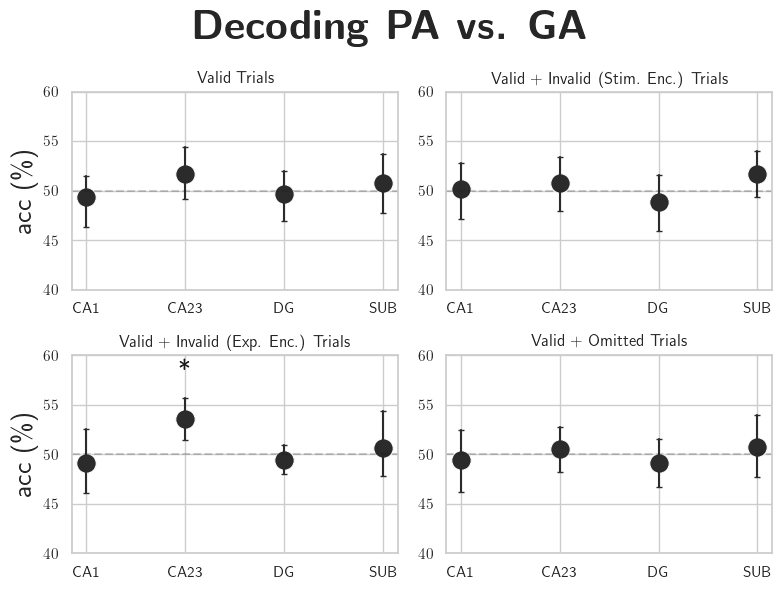

In [32]:
titles = ['Valid Trials', 'Valid + Invalid (Stim. Enc.) Trials', 'Valid + Invalid (Exp. Enc.) Trials', 'Valid + Omitted Trials']
fig, ax = plt.subplots(2,2, figsize=(1*len(regions)*2, 3*2))
palette = sns.color_palette('Grays')

all_decoding_results = [decoding_results, decoding_results_stim, decoding_results_pred, decoding_results_omis]

for test_idx, axis in enumerate(ax.ravel()):

    pvals_tvs0 = np.array([stats.non_parametric_permutation_ttest(np.array(all_decoding_results[test_idx][region]), popmean=0.5) for region in list(all_decoding_results[test_idx].keys())])
    reject, p_corrected = fdrcorrection(pvals_tvs0)
    stars = viz.pvals2stars(p_corrected)

    for idx in range(len(regions)):
        if stars[idx] != 'ns':
            axis.text(idx, 0.58*100, stars[idx], ha='center', va='bottom', color='k', weight='bold', fontsize=20)
    res = pd.DataFrame(all_decoding_results[test_idx])*100
    res = res.melt(var_name="x", value_name="y")
    sns.lineplot(data=res, x="x", y="y", errorbar=('ci', 95), marker='o', linestyle='', err_style='bars', markersize=14, err_kws={'capsize':2}, c=palette[-1], ax=axis)
    axis.set_ylim([0.4*100, 0.6*100])
    axis.set_xticks(range(len(regions)), all_decoding_results[test_idx].keys())
    if test_idx%2==0: 
        axis.set_ylabel(r'acc (\%)', fontsize=20, fontweight='bold')
    else:
        axis.set_ylabel(r'', fontsize=20, fontweight='bold')
    axis.set_xlabel('')
    axis.axhline(y=0.5*100, c='k', linestyle='--', alpha=0.2)
    axis.set_title(titles[test_idx])
plt.suptitle(r'$\textbf{Decoding PA vs. GA}$', fontsize=30)
plt.tight_layout()
# plt.savefig('./results/predictability_hippocampus.png', dpi=300)
plt.show()

# whatoff control

In [34]:

feature_percentage = 0.25

all_acc_random = {}
loop_r = tqdm(regions, leave=False)
for region in loop_r:
    loop_r.set_description_str(region)
    mean_accs = []

    subjects_loop = tqdm(subjects)
    for subject in subjects_loop:
        subjects_loop.set_description_str(subject)

        if region == 'CA23':
            df_betas = fat.preprocess_betas(
                subject,
                pd.concat([
                    fat.get_betas(sid=subject, region='CA1', hemisphere='both', dropna=True),
                    fat.get_betas(sid=subject, region='CA3', hemisphere='both', dropna=True)]),
                stimulus_type='sound',
                normalization_method=None,
                average_betas=False,
                use_inverted_run_types=True)
        else:
            df_betas = fat.preprocess_betas(
                subject,
                fat.get_betas(sid=subject, region=region, hemisphere='both', dropna=True),
                stimulus_type='sound',
                normalization_method=None,
                average_betas=False,
                use_inverted_run_types=True)
            
        df = df_betas.filter(regex='random').filter(regex=r'^(?!.*_omis$)')
        X = df.values.T
        y = df.columns.map(lambda x: 0. if '_pa' in x else 1.).values

        mean_accs.append(np.mean(train_predict_region(X, y, meta_X=None, feature_percentage=feature_percentage)))

        subjects_loop.set_postfix_str(f'{np.mean(mean_accs):0.2f}')

    all_acc_random[region] = mean_accs 

decoding_results_random = {region: all_acc_random[region] for region in regions}

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

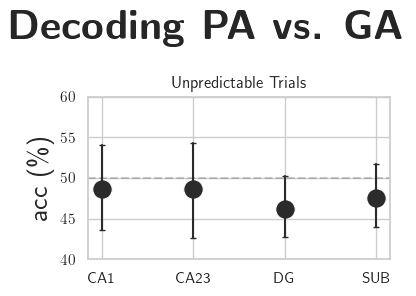

In [37]:

titles = ['Unpredictable Trials']
fig, axis = plt.subplots(1,1, figsize=(1*len(regions), 3))
palette = sns.color_palette('Grays')

all_decoding_results_random = [decoding_results_random]

pvals_tvs0 = np.array([stats.non_parametric_permutation_ttest(np.array(all_decoding_results_random[0][region]), popmean=0.5) for region in list(all_decoding_results_random[0].keys())])
reject, p_corrected = fdrcorrection(pvals_tvs0)
stars = viz.pvals2stars(p_corrected)

for idx in range(len(regions)):
    if stars[idx] != 'ns':
        axis.text(idx, 0.58*100, stars[idx], ha='center', va='bottom', color='k', weight='bold', fontsize=20)
res = pd.DataFrame(all_decoding_results_random[0])*100
res = res.melt(var_name="x", value_name="y")
sns.lineplot(data=res, x="x", y="y", errorbar=('ci', 95), marker='o', linestyle='', err_style='bars', markersize=14, err_kws={'capsize':2}, c=palette[-1], ax=axis)
axis.set_ylim([0.4*100, 0.6*100])
axis.set_xticks(range(len(regions)), all_decoding_results_random[0].keys())
if 0%2==0: 
    axis.set_ylabel(r'acc (\%)', fontsize=20, fontweight='bold')
else:
    axis.set_ylabel(r'', fontsize=20, fontweight='bold')
axis.set_xlabel('')
axis.axhline(y=0.5*100, c='k', linestyle='--', alpha=0.2)
axis.set_title(titles[0])

plt.suptitle(r'$\textbf{Decoding PA vs. GA}$', fontsize=30)
plt.tight_layout()
# plt.savefig('./results/predictability_hippocampus.png', dpi=300)
plt.show()

# Final Figure

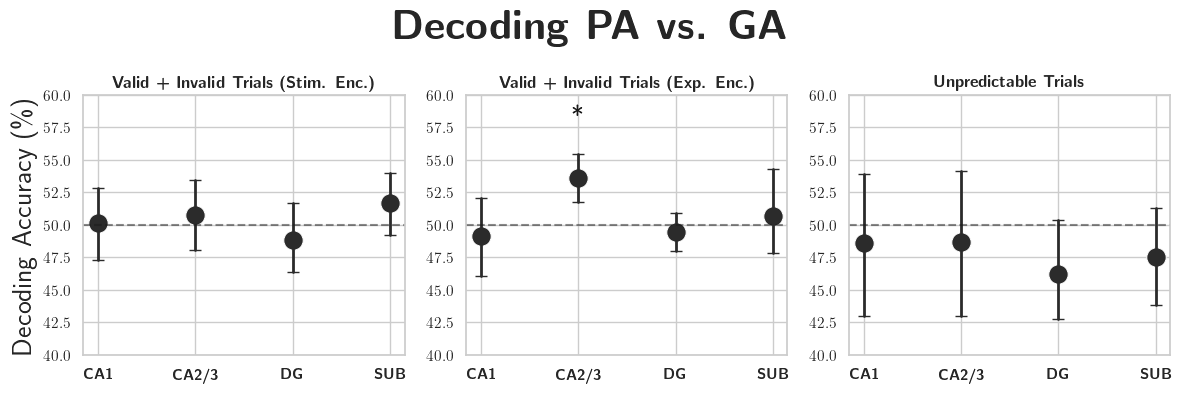

In [43]:
titles = ['Valid + Invalid Trials (Stim. Enc.)', 'Valid + Invalid Trials (Exp. Enc.)', 'Unpredictable Trials']
fig, ax = plt.subplots(1,3, figsize=(1*len(regions)*3, 4))
palette = sns.color_palette('Grays')

all_decoding_results = [decoding_results_stim, decoding_results_pred, decoding_results_random]

for test_idx, axis in enumerate(ax.ravel()):

    pvals_tvs0 = np.array([stats.non_parametric_permutation_ttest(np.array(all_decoding_results[test_idx][region]), popmean=0.5) for region in list(all_decoding_results[test_idx].keys())])
    reject, p_corrected = fdrcorrection(pvals_tvs0)
    stars = viz.pvals2stars(p_corrected)

    for idx in range(len(regions)):
        if stars[idx] != 'ns':
            axis.text(idx, 0.58*100, stars[idx], ha='center', va='bottom', color='k', weight='bold', fontsize=20)
    res = pd.DataFrame(all_decoding_results[test_idx])*100
    res = res.melt(var_name="x", value_name="y")
    sns.lineplot(data=res, x="x", y="y", errorbar=('ci', 95), marker='o', linestyle='', err_style='bars', markersize=14, err_kws={'capsize':4, 'linewidth':2}, c=palette[-1], ax=axis)
    axis.set_ylim([0.4*100, 0.6*100])
    axis.set_xticks(range(len(regions)), [r'$\textbf{CA1}$', r'$\textbf{CA2/3}$', r'$\textbf{DG}$', r'$\textbf{SUB}$'])
    if test_idx==0: 
        axis.set_ylabel(r'Decoding Accuracy (\%)', fontsize=20, fontweight='bold')
    else:
        axis.set_ylabel(r'', fontsize=20, fontweight='bold')
    axis.set_xlabel('')
    axis.axhline(y=0.5*100, c='k', linestyle='--', alpha=0.5)
    axis.set_title(r'$\textbf{'+titles[test_idx]+'}$')

plt.suptitle(r'$\textbf{Decoding PA vs. GA}$', fontsize=30)
plt.tight_layout()
plt.savefig('./results/predictability_hippocampus.png', dpi=300)
plt.show()

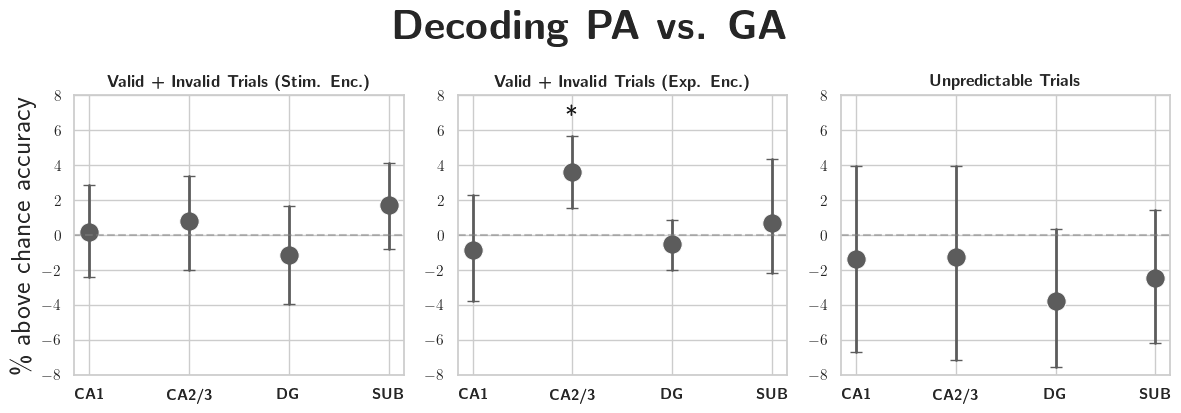

In [42]:
titles = ['Valid + Invalid Trials (Stim. Enc.)', 'Valid + Invalid Trials (Exp. Enc.)', 'Unpredictable Trials']
fig, ax = plt.subplots(1,3, figsize=(1*len(regions)*3, 4.2))
palette = sns.color_palette('Grays')

all_decoding_results = [decoding_results_stim, decoding_results_pred, decoding_results_random]

for test_idx, axis in enumerate(ax.ravel()):

    pvals_tvs0 = np.array([stats.non_parametric_permutation_ttest(np.array(all_decoding_results[test_idx][region]), popmean=0.5) for region in list(all_decoding_results[test_idx].keys())])
    reject, p_corrected = fdrcorrection(pvals_tvs0)
    stars = viz.pvals2stars(p_corrected)

    for idx in range(len(regions)):
        if stars[idx] != 'ns':
            axis.text(idx, 6.5, stars[idx], ha='center', va='bottom', color='k', weight='bold', fontsize=20)
    all_decoding_results_shifted = {k:(np.array(v)-0.5)*100 for k,v in all_decoding_results[test_idx].items()}
    res = pd.DataFrame(all_decoding_results_shifted)
    res = res.melt(var_name="x", value_name="y")
    sns.lineplot(data=res, x="x", y="y", errorbar=('ci', 95), marker='o', linestyle='', err_style='bars', markersize=14, err_kws={'capsize':4, 'linewidth':2}, c=palette[-2], ax=axis)
    axis.set_ylim([-8, 8])
    axis.set_xticks(range(len(regions)), [r'$\textbf{CA1}$', r'$\textbf{CA2/3}$', r'$\textbf{DG}$', r'$\textbf{SUB}$'])
    if test_idx==0: 
        axis.set_ylabel(r'\% above chance accuracy', fontsize=20, fontweight='bold')
    else:
        axis.set_ylabel(r'', fontsize=20, fontweight='bold')
    axis.set_xlabel('')
    axis.axhline(y=0.0, c='gray', linestyle='--', alpha=0.5)
    axis.set_title(r'$\textbf{'+titles[test_idx]+'}$')

plt.suptitle(r'$\textbf{Decoding PA vs. GA}$', fontsize=30)
plt.tight_layout()
plt.savefig('./results/predictability_hippocampus.png', dpi=300)
plt.show()

### Write results as latex tables

In [15]:
for test_idx, axis in enumerate(ax.ravel()):

    pvals_tvs0 = np.array([stats.non_parametric_permutation_ttest(np.array(all_decoding_results[test_idx][region]), popmean=0.5) for region in list(all_decoding_results[test_idx].keys())])
    # tvals = np.array([ttest_rel(np.array(all_decoding_results[test_idx][region])) for region in list(all_decoding_results[test_idx].keys())])

    reject, p_corrected = fdrcorrection(pvals_tvs0)
    accs = np.array([np.mean(all_decoding_results[test_idx][region]) for region in regions])
    df = pd.DataFrame(np.array([accs*100, pvals_tvs0, p_corrected]).T, columns=['acc (%)', 'p-value', 'q(FDR)'], index=regions)
    print(df.to_latex())

\begin{tabular}{lrrr}
\toprule
 & acc (%) & p-value & q(FDR) \\
\midrule
CA1 & 50.162338 & 0.900879 & 0.900879 \\
CA23 & 50.757576 & 0.614746 & 0.819661 \\
DG & 48.809524 & 0.408691 & 0.817383 \\
SUB & 51.677489 & 0.230957 & 0.817383 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrr}
\toprule
 & acc (%) & p-value & q(FDR) \\
\midrule
CA1 & 49.134199 & 0.636230 & 0.802246 \\
CA23 & 53.571429 & 0.010254 & 0.041016 \\
DG & 49.458874 & 0.531738 & 0.802246 \\
SUB & 50.649351 & 0.802246 & 0.802246 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrr}
\toprule
 & acc (%) & p-value & q(FDR) \\
\midrule
CA1 & 48.593074 & 0.647949 & 0.687012 \\
CA23 & 50.865801 & 0.687012 & 0.687012 \\
DG & 46.212121 & 0.094238 & 0.376953 \\
SUB & 47.510823 & 0.250488 & 0.500977 \\
\bottomrule
\end{tabular}



---